In [1]:
import sys
import os
from importlib import reload
import pylab as plt
import skimage
import numpy as np
from skimage import exposure

sys.path.insert(0, '../../src')
import deepgeo.dataset.image_utils as iutils
import deepgeo.common.geofunctions as gf
import deepgeo.common.visualization as vis

reload(iutils)
reload(gf)
reload(vis)

<module 'deepgeo.common.visualization' from '../../src/deepgeo/common/visualization.py'>

In [2]:
DATA_DIR = "/home/raian/doutorado/Dados/generated"

bands = ['pixel_qa', 'green', 'red', 'nir', 'swir_1', 'swir_2']

shp_ref = os.path.join(DATA_DIR, "Prodes_mosaic.shp")

stacking: 
 /home/raian/doutorado/Dados/generated/mosaic_2013.tif /home/raian/doutorado/Dados/generated/mosaic_2014.tif


/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


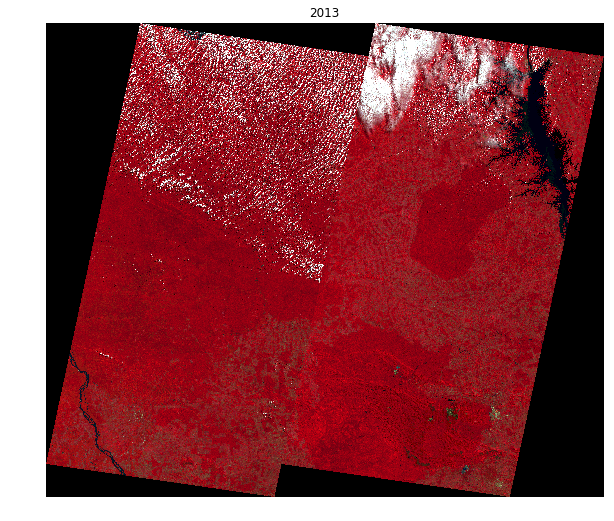

/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


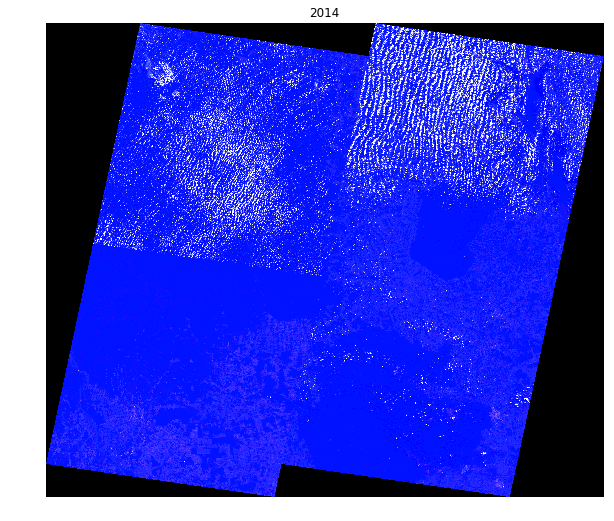

stacking: 
 /home/raian/doutorado/Dados/generated/mosaic_2014.tif /home/raian/doutorado/Dados/generated/mosaic_2015.tif


/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


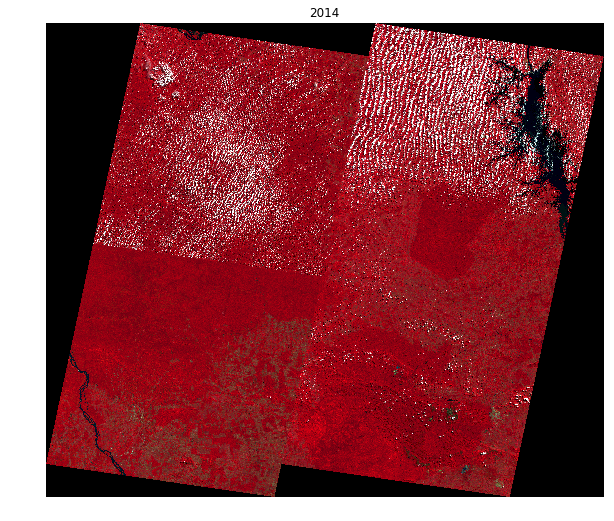

/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


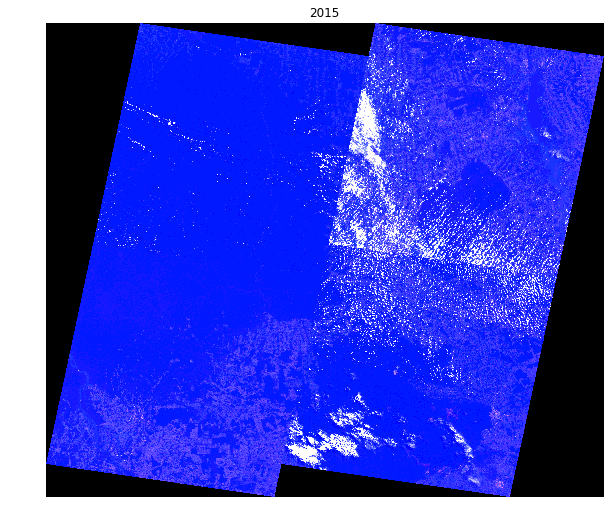

stacking: 
 /home/raian/doutorado/Dados/generated/mosaic_2015.tif /home/raian/doutorado/Dados/generated/mosaic_2016.tif


/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


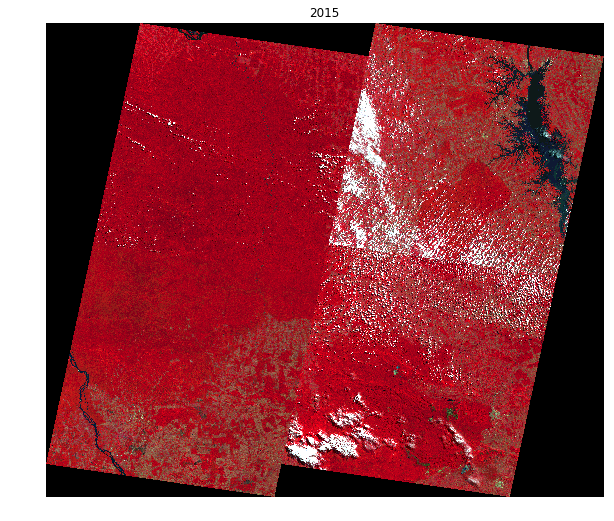

/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


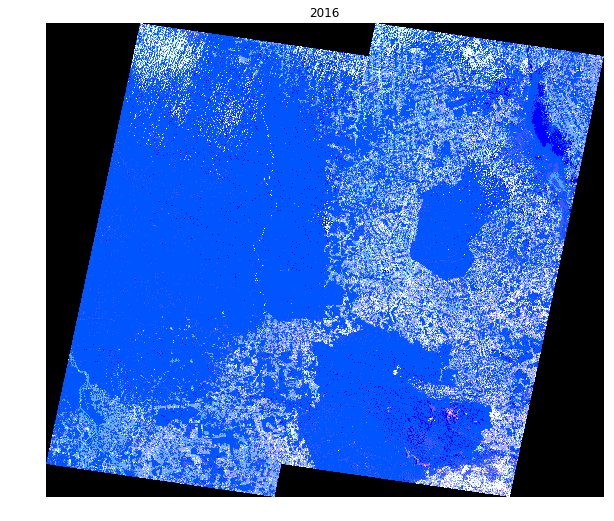

stacking: 
 /home/raian/doutorado/Dados/generated/mosaic_2016.tif /home/raian/doutorado/Dados/generated/mosaic_2017.tif


/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


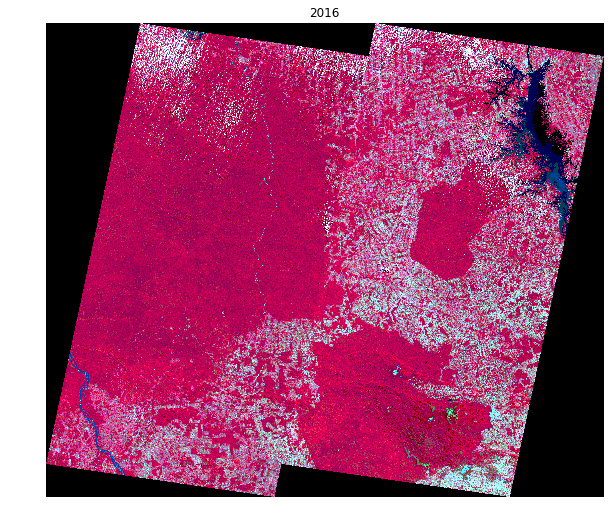

/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


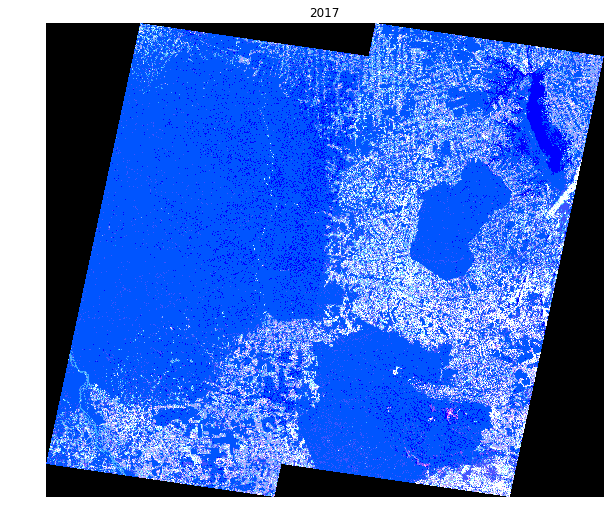

stacking: 
 /home/raian/doutorado/Dados/generated/mosaic_2017.tif /home/raian/doutorado/Dados/generated/mosaic_2018.tif


/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


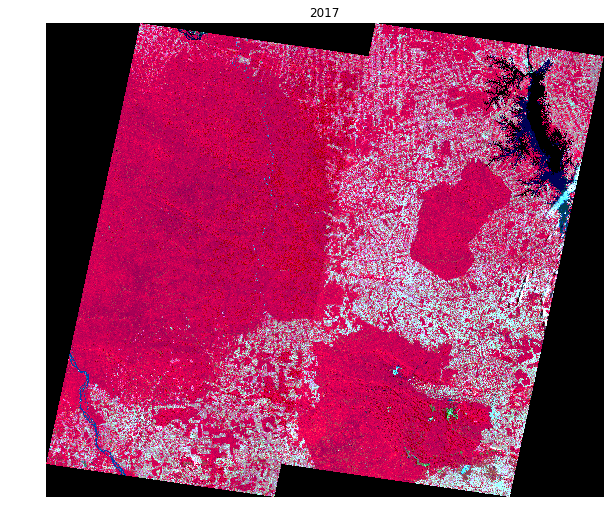

/home/raian/anaconda3/envs/tensorflow/lib/python3.5/site-packages/skimage/util/dtype.py:122: UserWarning: Possible precision loss when converting from uint16 to uint8
  .format(dtypeobj_in, dtypeobj_out))


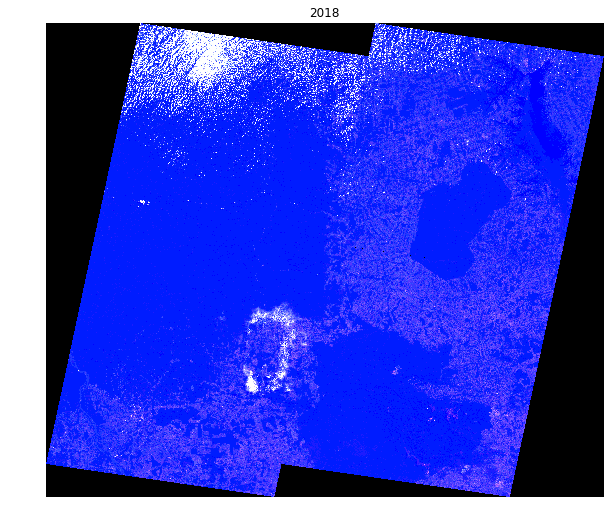

In [3]:
for year in range(2013, 2018):
    input_files = [os.path.join(DATA_DIR, ('mosaic_' + str(year) + '.tif')),
                   os.path.join(DATA_DIR, ('mosaic_' + str(year + 1) + '.tif'))]
    
    out_img = os.path.join(DATA_DIR, 'stacked_mosaic_' + str(year) + '_' + str(year + 1) + '.tif')
    
    bands_y1 = []
    bands_y2 = []
    for b in bands:
        bands_y1.append(b + '_' + str(year))
        bands_y2.append(b + '_' + str(year + 1))
        band_names = bands_y1 + bands_y2
    
    iutils.stack_temporal_images(input_files, out_img, band_names)
    
    raster_img = gf.load_image(out_img, no_data=-9999)
    vis.plot_rgb_img(raster_img, bands=[3,2,1], contrast=True, title=str(year))
    vis.plot_rgb_img(raster_img, bands=[8,7,6], contrast=True, title=str(year + 1))